<a href="https://colab.research.google.com/github/priya5032007/Datascience/blob/main/OTT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("shows_data_uncleaned.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.columns.tolist())
display(df.head())

Rows: 102
Columns: 8
['Show_ID', 'Genre', 'Language', 'Runtime', 'Release_Year', 'Budget', 'Rating', 'Viewership']


,Show_ID,Genre,Language,Runtime,Release_Year,Budget,Rating,Viewership
0,SHOW_001,Drama,English,122.0,2023,58.07,7.2,46.73
1,SHOW_002,Comedy,English,102.0,2022,143.14,6.4,78.29
2,SHOW_003,Sci-Fi,English,34.0,2023,109.87,8.4,87.67
3,SHOW_004,Drama,Spanish,107.0,2022,89.92,8.6,83.94
4,SHOW_005,Comedy,Spanish,119.0,2023,46.70,8.0,46.68


In [3]:
df = pd.read_csv("shows_data_uncleaned.csv")

print("Original Dataset")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

df = df.drop_duplicates()

df["Genre"] = df["Genre"].str.strip().str.title()
df["Language"] = df["Language"].str.strip().str.title()

df["Genre"] = df["Genre"].replace({
    "Scifi": "Sci-Fi"
})

df["Runtime"] = pd.to_numeric(df["Runtime"], errors="coerce")
df["Release_Year"] = pd.to_numeric(df["Release_Year"], errors="coerce")
df["Budget"] = pd.to_numeric(df["Budget"], errors="coerce")
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Viewership"] = pd.to_numeric(df["Viewership"], errors="coerce")

df.loc[df["Runtime"] <= 0, "Runtime"] = np.nan
df.loc[df["Budget"] <= 0, "Budget"] = np.nan
df.loc[(df["Rating"] < 0) | (df["Rating"] > 10), "Rating"] = np.nan
df.loc[df["Viewership"] < 0, "Viewership"] = np.nan

df["Genre"] = df["Genre"].fillna(df["Genre"].mode()[0])
df["Runtime"] = df["Runtime"].fillna(df["Runtime"].median())
df["Budget"] = df["Budget"].fillna(df["Budget"].median())
df["Rating"] = df["Rating"].fillna(df["Rating"].median())
df["Viewership"] = df["Viewership"].fillna(df["Viewership"].median())

df["Language"] = df["Language"].replace({
    "English": "English"
})

df.loc[df["Viewership"] > 500, "Viewership"] = np.nan
df["Viewership"] = df["Viewership"].fillna(df["Viewership"].median())

print("\nAfter Cleaning")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nDescriptive Statistics")
print(df.describe())

display(df.head(10))

df.to_csv("shows_data_cleaned.csv", index=False)

print("\nCleaned dataset saved successfully")

Original Dataset
Rows: 102
Columns: 8

Missing Values
Show_ID         0
Genre           1
Language        0
Runtime         0
Release_Year    0
Budget          1
Rating          1
Viewership      0
dtype: int64

Duplicate Rows
2

After Cleaning
Rows: 100
Columns: 8

Missing Values
Show_ID         0
Genre           0
Language        0
Runtime         0
Release_Year    0
Budget          0
Rating          0
Viewership      0
dtype: int64

Duplicate Rows
0

Descriptive Statistics
          Runtime  Release_Year      Budget      Rating  Viewership
count  100.000000    100.000000  100.000000  100.000000  100.000000
mean   109.560000   2022.010000   63.119600    7.695000   57.293200
std     21.564243      1.210184   39.503592    0.612558   21.580912
min     34.000000   2020.000000    8.000000    6.200000   26.400000
25%     94.000000   2021.000000   30.875000    7.200000   38.575000
50%    110.000000   2022.000000   53.000000    7.800000   51.000000
75%    126.500000   2023.000000   92.750000

,Show_ID,Genre,Language,Runtime,Release_Year,Budget,Rating,Viewership
0,SHOW_001,Drama,English,122.0,2023,58.07,7.2,46.73
1,SHOW_002,Comedy,English,102.0,2022,143.14,6.4,78.29
2,SHOW_003,Sci-Fi,English,34.0,2023,109.87,8.4,87.67
3,SHOW_004,Drama,Spanish,107.0,2022,89.92,8.6,83.94
4,SHOW_005,Comedy,Spanish,119.0,2023,46.70,8.0,46.68
5,SHOW_006,Drama,Japanese,40.0,2024,24.10,8.3,47.88
6,SHOW_007,Comedy,French,122.0,2021,11.23,6.2,31.76
7,SHOW_008,Documentary,English,141.0,2021,130.82,7.5,78.23
8,SHOW_009,Drama,Hindi,110.0,2022,32.33,7.6,41.97
9,SHOW_010,Drama,Korean,107.0,2022,106.33,8.0,76.54



Cleaned dataset saved successfully


In [4]:
from google.colab import files

files.download("shows_data_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
success_threshold = df["Viewership"].median()

df["Success"] = np.where(
    df["Viewership"] >= success_threshold,
    "Successful",
    "Less Successful"
)

print("Success Threshold:", success_threshold)

print("\nSuccess Distribution")
print(df["Success"].value_counts())

Success Threshold: 51.0

Success Distribution
Success
Successful         51
Less Successful    49
Name: count, dtype: int64


In [6]:
success_threshold = df["Viewership"].median()

df["Success"] = np.where(
    df["Viewership"] >= success_threshold,
    "Successful",
    "Less Successful"
)

print("Success Threshold:", success_threshold)

print("\nSuccess Distribution")
print(df["Success"].value_counts())

Success Threshold: 51.0

Success Distribution
Success
Successful         51
Less Successful    49
Name: count, dtype: int64


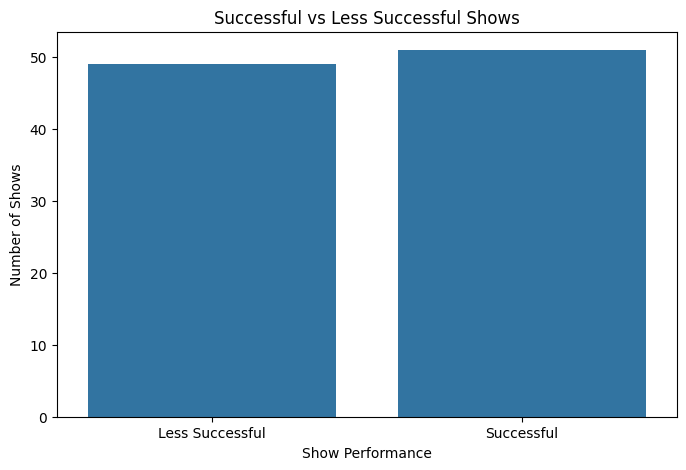

In [7]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Success"
)

plt.title("Successful vs Less Successful Shows")
plt.xlabel("Show Performance")
plt.ylabel("Number of Shows")
plt.show()

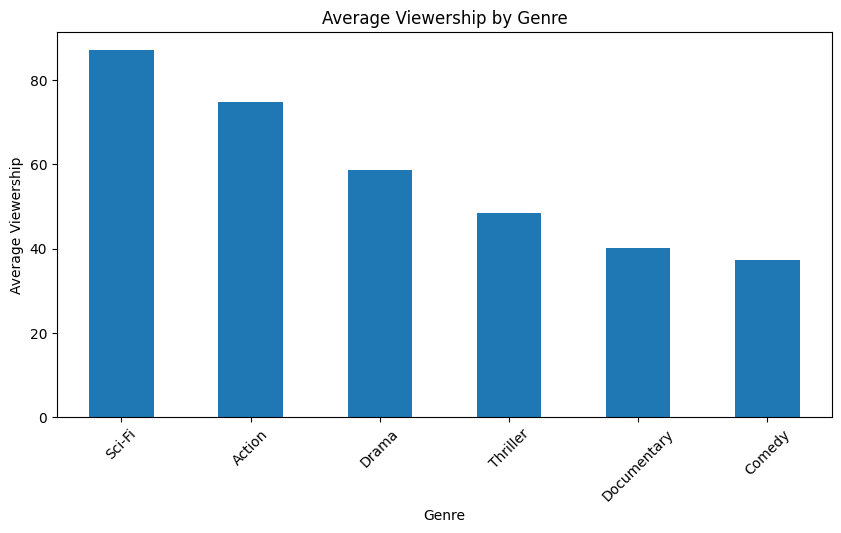

In [8]:
genre_viewership = (
    df.groupby("Genre")["Viewership"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

genre_viewership.plot(kind="bar")

plt.title("Average Viewership by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Viewership")
plt.xticks(rotation=45)
plt.show()

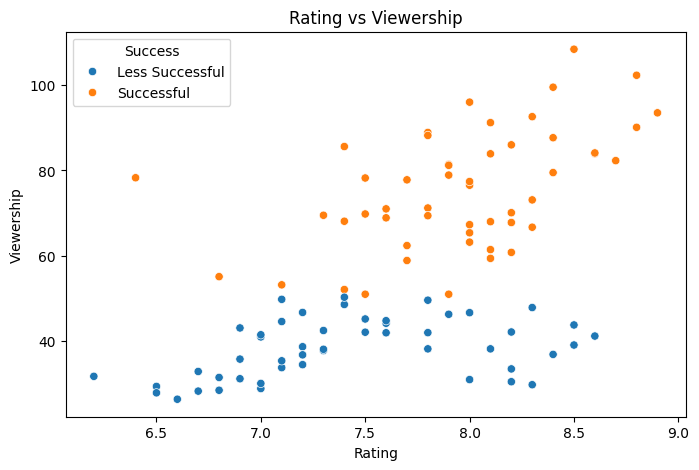

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Rating",
    y="Viewership",
    hue="Success"
)

plt.title("Rating vs Viewership")
plt.xlabel("Rating")
plt.ylabel("Viewership")
plt.show()

In [ ]:
language_viewership = (
    df.groupby("Language")["Viewership"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

language_viewership.plot(kind="bar")

plt.title("Average Viewership by Language")
plt.xlabel("Language")
plt.ylabel("Average Viewership")
plt.xticks(rotation=45)
plt.show()

In [10]:
combination = (
    df.groupby(["Genre", "Language"])
    .agg(
        Average_Viewership=("Viewership", "mean"),
        Average_Rating=("Rating", "mean"),
        Average_Budget=("Budget", "mean"),
        Show_Count=("Show_ID", "count")
    )
    .sort_values("Average_Viewership", ascending=False)
)

display(combination.head(10))

Average_Viewership  Average_Rating  Average_Budget  \
Genre  Language                                                       
Sci-Fi English            94.152857        8.357143      128.267143   
       Korean             86.000000        8.200000      115.000000   
Drama  Korean             85.308000        8.600000       89.566000   
Sci-Fi Japanese           81.400000        7.900000      110.000000   
Action English            79.866667        7.633333      121.816667   
       Korean             77.550000        7.950000      101.600000   
       Spanish            77.227500        7.775000       97.800000   
Sci-Fi Spanish            69.400000        7.800000       95.000000   
Action Hindi              68.933333        7.500000       92.000000   
       Japanese           67.300000        8.000000       82.000000   

                 Show_Count  
Genre  Language              
Sci-Fi English            7  
       Korean             1  
Drama  Korean             5  
Sci-Fi Japanese           1  
Action English            6  
       Korean             2  
       Spanish            4  
Sci-Fi Spanish            1  
Action Hindi              3  
       Japanese           1

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

X = df[
    [
        "Genre",
        "Language",
        "Runtime",
        "Release_Year",
        "Budget",
        "Rating"
    ]
]

y = df["Success"]

categorical_features = [
    "Genre",
    "Language"
]

numeric_features = [
    "Runtime",
    "Release_Year",
    "Budget",
    "Rating"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.95

Classification Report:
                 precision    recall  f1-score   support

Less Successful       1.00      0.90      0.95        10
     Successful       0.91      1.00      0.95        10

       accuracy                           0.95        20
      macro avg       0.95      0.95      0.95        20
   weighted avg       0.95      0.95      0.95        20


Confusion Matrix:
[[ 9  1]
 [ 0 10]]


In [13]:
rf = model.named_steps["classifier"]
preprocessor_fitted = model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importance.head(10))

num__Budget               0.469744
num__Runtime              0.214272
num__Rating               0.089109
num__Release_Year         0.054213
cat__Genre_Comedy         0.038987
cat__Genre_Action         0.028859
cat__Genre_Sci-Fi         0.019860
cat__Genre_Documentary    0.015213
cat__Language_French      0.014542
cat__Genre_Drama          0.013544
dtype: float64


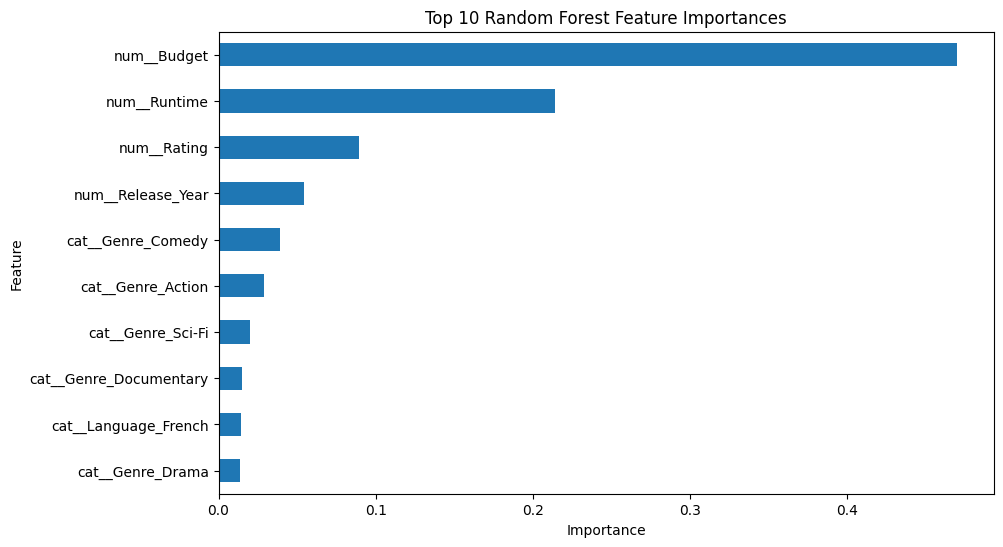

In [14]:
plt.figure(figsize=(10, 6))

importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()